# AUTO ARIMA

## IMPORTS

In [8]:
# Dataset import
from ucimlrepo import fetch_ucirepo

# General imports
import numpy as np
import pandas as pd 

# Visualization imports
import matplotlib.pyplot as plt
import seaborn as sns

#Model import
from pmdarima import auto_arima

#Validation import
import scipy.stats as stats
from statsmodels.stats.diagnostic import acorr_ljungbox

## DATASET LOADING

In [2]:
# fetch dataset 
bike_sharing = fetch_ucirepo(id=275) 
  
# original df 
df = bike_sharing.data.original

# variable information 
print(bike_sharing.variables)

print(df.head())

          name     role         type demographic  \
0      instant       ID      Integer        None   
1       dteday  Feature         Date        None   
2       season  Feature  Categorical        None   
3           yr  Feature  Categorical        None   
4         mnth  Feature  Categorical        None   
5           hr  Feature  Categorical        None   
6      holiday  Feature       Binary        None   
7      weekday  Feature  Categorical        None   
8   workingday  Feature       Binary        None   
9   weathersit  Feature  Categorical        None   
10        temp  Feature   Continuous        None   
11       atemp  Feature   Continuous        None   
12         hum  Feature   Continuous        None   
13   windspeed  Feature   Continuous        None   
14      casual    Other      Integer        None   
15  registered    Other      Integer        None   
16         cnt   Target      Integer        None   

                                          description units mis

## AUTO ARIMA MODELING

### Data partitioning

In [3]:
df['dteday'] = pd.to_datetime(df['dteday'])

train_size = int(len(df)-24)
train, test = df.iloc[:train_size], df.iloc[train_size:]


### Model training

#### Without seasonality (ARIMA)

In [4]:
# Model adjustment non-seasonal
#Registered model
model_reg_no_seas = auto_arima(train['registered'], 
                               seasonal=False, 
                               stepwise=True,
                               suppress_warnings=True,
                               trace=True)

#Casual model
model_cas_no_seas = auto_arima(train['casual'], 
                               seasonal=False, 
                               stepwise=True, 
                               suppress_warnings=True,
                               trace=True)

#predictions for 24 hours
preds_reg = model_reg_no_seas.predict(n_periods=24)
preds_cas = model_cas_no_seas.predict(n_periods=24)

final_prediction_no_seas = preds_reg + preds_cas

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=11.47 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=207307.902, Time=0.23 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=205880.588, Time=0.52 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=204659.258, Time=2.08 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=207305.902, Time=0.13 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=204556.703, Time=4.94 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=203522.977, Time=4.34 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=203565.012, Time=1.54 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=24.06 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=32.03 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : AIC=203531.414, Time=1.81 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=34.04 sec
 ARIMA(2,1,1)(0,0,0)[0]             : AIC=203520.977, Time=1.52 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=204554.703, Time=2.39 sec
 ARIMA(2,1,0)(0,0,0)[0]      

#### With seasonality (SARIMA)

In [5]:
# Model adjustment seasonal
#Registered model
model_reg_seas = auto_arima(train['registered'], 
                               seasonal=True,
                               m = 24,
                               max_p=2, max_q=2,
                               max_P=1, max_Q=1,
                               stepwise=True,
                               suppress_warnings=True,
                               trace=True)

#Casual model
model_cas_seas = auto_arima(train['casual'], 
                               seasonal=True,
                               m = 24,
                               max_p=2, max_q=2,
                               max_P=1, max_Q=1,
                               stepwise=True, 
                               suppress_warnings=True,
                               trace=True)

#predictions for 24 hours
preds_reg = model_reg_seas.predict(n_periods=24)
preds_cas = model_cas_seas.predict(n_periods=24)

final_prediction_seas = preds_reg + preds_cas

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[24] intercept   : AIC=inf, Time=100.59 sec
 ARIMA(0,1,0)(0,0,0)[24] intercept   : AIC=207307.902, Time=0.27 sec
 ARIMA(1,1,0)(1,0,0)[24] intercept   : AIC=194526.784, Time=31.86 sec
 ARIMA(0,1,1)(0,0,1)[24] intercept   : AIC=197320.204, Time=18.39 sec
 ARIMA(0,1,0)(0,0,0)[24]             : AIC=207305.902, Time=0.13 sec
 ARIMA(1,1,0)(0,0,0)[24] intercept   : AIC=205880.588, Time=0.55 sec
 ARIMA(1,1,0)(1,0,1)[24] intercept   : AIC=195070.824, Time=27.52 sec
 ARIMA(1,1,0)(0,0,1)[24] intercept   : AIC=197881.418, Time=18.63 sec
 ARIMA(0,1,0)(1,0,0)[24] intercept   : AIC=195012.598, Time=8.52 sec
 ARIMA(2,1,0)(1,0,0)[24] intercept   : AIC=193062.414, Time=39.17 sec
 ARIMA(2,1,0)(0,0,0)[24] intercept   : AIC=203565.012, Time=0.79 sec
 ARIMA(2,1,0)(1,0,1)[24] intercept   : AIC=193052.237, Time=42.52 sec
 ARIMA(2,1,0)(0,0,1)[24] intercept   : AIC=196280.759, Time=26.30 sec
 ARIMA(2,1,1)(1,0,1)[24] intercept   : AIC=inf, Time=85.90

#### With seasonality and exogenous variables (SARIMAX)

In [6]:
exog_cols = ['temp', 'hum', 'windspeed', 'workingday', 'holiday']
X_train = train[exog_cols]
X_test = test[exog_cols]

#Registered model
model_reg_seas_exog = auto_arima(train['registered'], 
                               seasonal=True,
                               X = X_train,
                               max_p=2, max_q=2,
                               max_P=1, max_Q=1,
                               m = 24,
                               stepwise=True,
                               suppress_warnings=True,
                               trace=True)

#Casual model
model_cas_seas_exog = auto_arima(train['casual'], 
                               seasonal=True,
                               X = X_train,
                               max_p=2, max_q=2,
                               max_P=1, max_Q=1,
                               m = 24,
                               stepwise=True, 
                               suppress_warnings=True,
                               trace=True)

#predictions for 24 hours
preds_reg = model_reg_seas_exog.predict(n_periods=24, X=X_test)
preds_cas = model_cas_seas_exog.predict(n_periods=24, X=X_test)

final_prediction_seas_exog = preds_reg + preds_cas

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[24] intercept   : AIC=inf, Time=163.81 sec
 ARIMA(0,1,0)(0,0,0)[24] intercept   : AIC=207209.908, Time=0.63 sec
 ARIMA(1,1,0)(1,0,0)[24] intercept   : AIC=194550.447, Time=198.79 sec
 ARIMA(0,1,1)(0,0,1)[24] intercept   : AIC=197346.974, Time=83.31 sec
 ARIMA(0,1,0)(0,0,0)[24]             : AIC=207207.908, Time=6.33 sec
 ARIMA(1,1,0)(0,0,0)[24] intercept   : AIC=205879.613, Time=1.40 sec
 ARIMA(1,1,0)(1,0,1)[24] intercept   : AIC=195109.686, Time=88.49 sec
 ARIMA(1,1,0)(0,0,1)[24] intercept   : AIC=197894.832, Time=60.56 sec
 ARIMA(0,1,0)(1,0,0)[24] intercept   : AIC=194992.960, Time=79.12 sec
 ARIMA(2,1,0)(1,0,0)[24] intercept   : AIC=193108.637, Time=222.86 sec
 ARIMA(2,1,0)(0,0,0)[24] intercept   : AIC=203497.100, Time=2.02 sec
 ARIMA(2,1,0)(1,0,1)[24] intercept   : AIC=193099.889, Time=204.18 sec
 ARIMA(2,1,0)(0,0,1)[24] intercept   : AIC=196332.973, Time=61.11 sec
 ARIMA(2,1,1)(1,0,1)[24] intercept   : AIC=inf, Time=1

### Validation phase

#### No Seasonality Validation

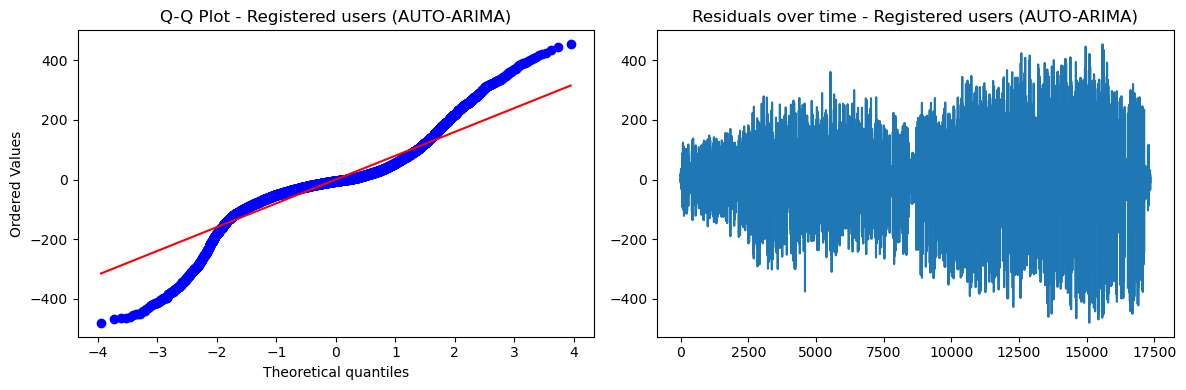

        lb_stat  lb_pvalue
10  2740.608742        0.0
20  4525.431373        0.0


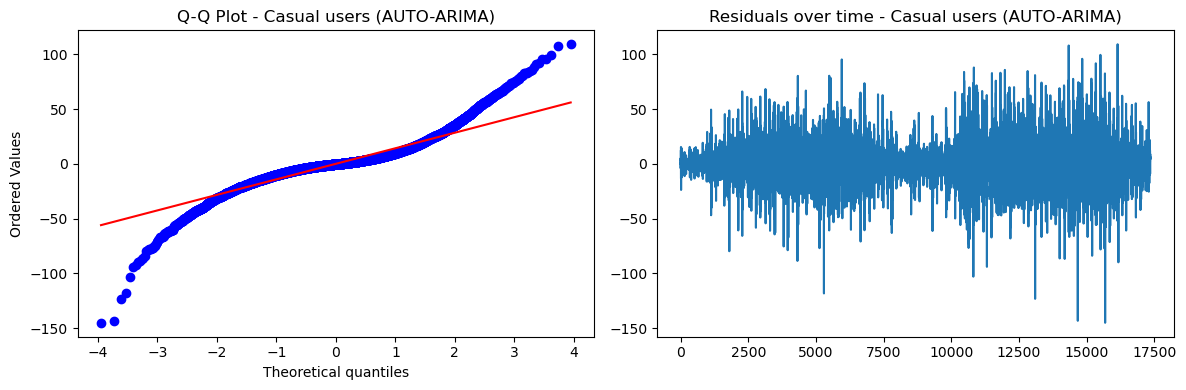

       lb_stat      lb_pvalue
10  123.742371   8.789290e-22
20  592.927198  8.888241e-113


In [10]:
#Registered odel validation
residuals_registered = model_reg_no_seas.resid()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
stats.probplot(residuals_registered, dist="norm", plot=axes[0])
axes[0].set_title(f"Q-Q Plot - Registered users (AUTO-ARIMA)")
axes[1].plot(residuals_registered)
axes[1].set_title(f"Residuals over time - Registered users (AUTO-ARIMA)")
plt.tight_layout()
plt.show()

lb_result = acorr_ljungbox(residuals_registered, lags=[10, 20], return_df=True)
print(lb_result)

#Casual model validation
residuals_casual = model_cas_no_seas.resid()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
stats.probplot(residuals_casual, dist="norm", plot=axes[0])
axes[0].set_title(f"Q-Q Plot - Casual users (AUTO-ARIMA)")
axes[1].plot(residuals_casual)
axes[1].set_title(f"Residuals over time - Casual users (AUTO-ARIMA)")
plt.tight_layout()
plt.show()

lb_result = acorr_ljungbox(residuals_casual, lags=[10, 20], return_df=True)
print(lb_result)

#### Seasonality Validation

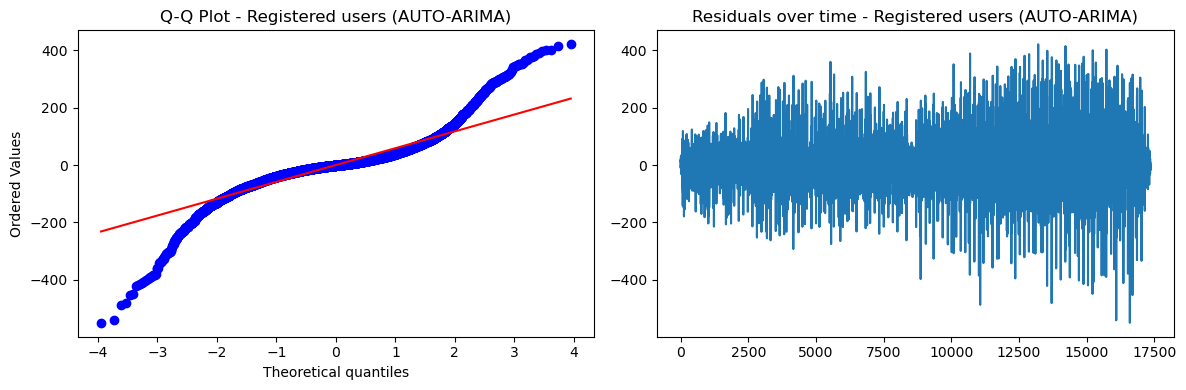

        lb_stat  lb_pvalue
10  2724.004843        0.0
20  3128.001656        0.0


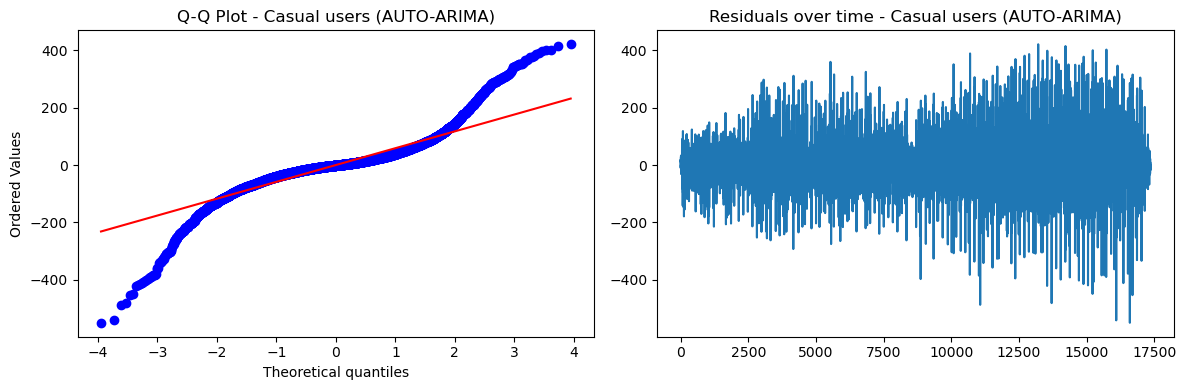

        lb_stat  lb_pvalue
10  2724.004843        0.0
20  3128.001656        0.0


In [ ]:
#Registered odel validation
residuals_registered = model_reg_seas.resid()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
stats.probplot(residuals_registered, dist="norm", plot=axes[0])
axes[0].set_title(f"Q-Q Plot - Registered users (AUTO-ARIMA)")
axes[1].plot(residuals_registered)
axes[1].set_title(f"Residuals over time - Registered users (AUTO-ARIMA)")
plt.tight_layout()
plt.show()

lb_result = acorr_ljungbox(residuals_registered, lags=[10, 20], return_df=True)
print(lb_result)

#Casual model validation
residuals_casual = model_cas_seas.resid()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
stats.probplot(residuals_casual, dist="norm", plot=axes[0])
axes[0].set_title(f"Q-Q Plot - Casual users (AUTO-ARIMA)")
axes[1].plot(residuals_casual)
axes[1].set_title(f"Residuals over time - Casual users (AUTO-ARIMA)")
plt.tight_layout()
plt.show()

lb_result = acorr_ljungbox(residuals_casual, lags=[10, 20], return_df=True)
print(lb_result)

#### Seasonality and exogenus Validation

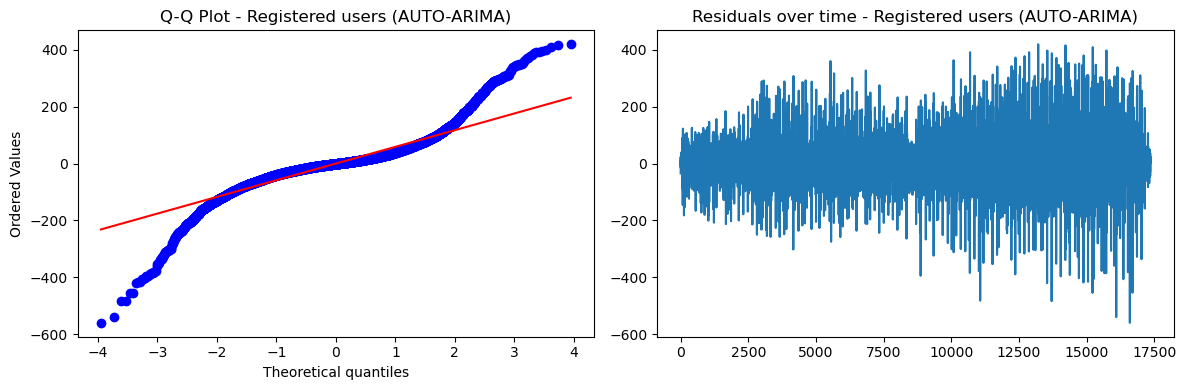

        lb_stat  lb_pvalue
10  2787.114919        0.0
20  3243.758992        0.0


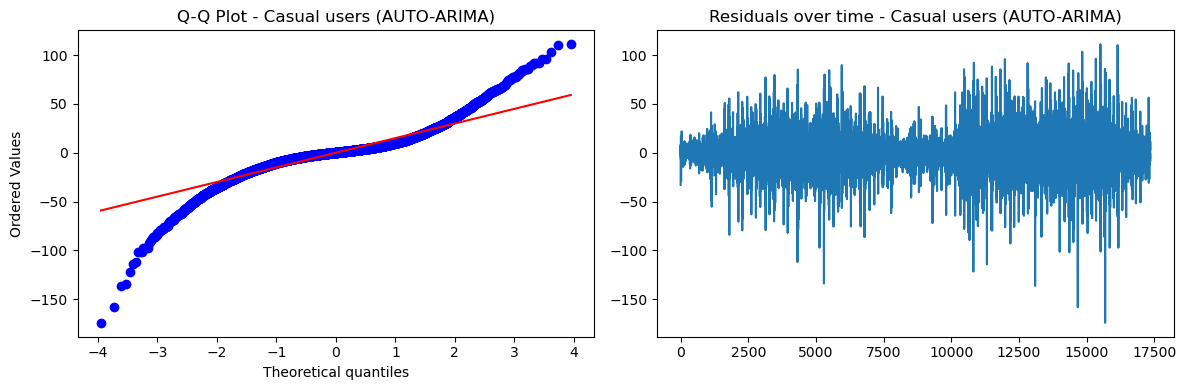

        lb_stat      lb_pvalue
10  1413.035292  1.520646e-297
20  2175.996497   0.000000e+00


In [12]:
#Registered odel validation
residuals_registered = model_reg_seas_exog.resid()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
stats.probplot(residuals_registered, dist="norm", plot=axes[0])
axes[0].set_title(f"Q-Q Plot - Registered users (AUTO-ARIMA)")
axes[1].plot(residuals_registered)
axes[1].set_title(f"Residuals over time - Registered users (AUTO-ARIMA)")
plt.tight_layout()
plt.show()

lb_result = acorr_ljungbox(residuals_registered, lags=[10, 20], return_df=True)
print(lb_result)

#Casual model validation
residuals_casual = model_cas_seas_exog.resid()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
stats.probplot(residuals_casual, dist="norm", plot=axes[0])
axes[0].set_title(f"Q-Q Plot - Casual users (AUTO-ARIMA)")
axes[1].plot(residuals_casual)
axes[1].set_title(f"Residuals over time - Casual users (AUTO-ARIMA)")
plt.tight_layout()
plt.show()

lb_result = acorr_ljungbox(residuals_casual, lags=[10, 20], return_df=True)
print(lb_result)